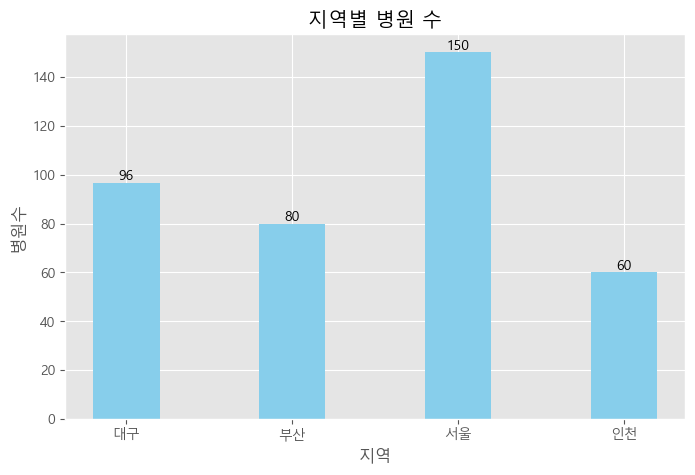

In [15]:
# 반드시 pandas는 import하여 사용한다.
import pandas as pd
# matplotlib 매트플롯립도 반드시 import하여 사용한다.
import matplotlib.pyplot as plt

# 데이터 생성하기
df1 = pd.DataFrame({
    "지역":["서울","부산","대구"],
    "총인구":[1000000,300000,200000]
})
df2 = pd.DataFrame({
    "지역":["서울","부산","인천"],
    "병원수":[150,80,60]
})

# 데이터 전처리를 위해 merge(병합)을 진행한다.
# outer로 병합하면 df1과 df2 합집합이 된다.
merged = pd.merge(df1, df2, on="지역",how="outer")
#merged

# 결측치 처리를 진행한다.
# 결측치는 병원수와, 총인구의 평균으로 정의한다.
merged['총인구'] = merged['총인구'].fillna(merged['총인구'].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
merged


# --------------------------------------
# 반드시 한글 깨짐 현상 코드를 삽입한다.
#----------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 차트 배경 + 색상 자동으로 그리드에 빨간색으로 지정
# plt.style.use('ggplot')


# 그래프 크기 지정 : figure(10,6)
plt.figure(figsize=(8,5))

# ------------------------------------
# 세로 막대 그래프 만들기 : plt.bar(x, y)
# x 축 : 지역, 가로축 : 병원수
# 세로막대 넓이 기본 값 : width=0.8
#--------------------------------------
bars = plt.bar(merged["지역"],merged["병원수"],width=0.4, color='skyblue')

# 차트제목, 가로축 제목, 세로축 제목 지정
plt.title("지역별 병원 수")
plt.xlabel("지역")
plt.ylabel("병원수")

# 세로막대 각각의 데이터 레이블 값 출력하는 방법
for bar in bars:
    height = bar.get_height() # 막대 높이 추출하는 함수 예) 대구 : 96
    # bar.get_x() : 막대그래프 넓이의 시작점을 추출
    # bar.get_width() : 막대그래프 넓이전체 추출 
    plt.text(bar.get_x() + bar.get_width()/2, 
            height, f'{int(height)}', ha='center',va='bottom')


# 반드시 저장이 먼저이다.
plt.savefig('hospital_chart.png',dpi=300)

# 그래프 출력
plt.show()